# HEVC vs VVC Experiment

**Data**

| Codec | QP | Bitrate_kbps | Y_PSNR_dB | Time_sec |
| :--- | :--- | :--- | :--- | :--- |
| HM | 22 | 6311.3760 | 43.2798 | 89.504 |
| HM | 27 | 3410.2560 | 41.5033 | 74.017 |
| HM | 32 | 2052.3360 | 39.1165 | 69.112 |
| HM | 37 | 1222.8000 | 36.2630 | 61.474 |
| VTM | 22 | 4727.0400 | 44.0691 | 570.181 |
| VTM | 27 | 2568.0480 | 42.5558 | 334.987 |
| VTM | 32 | 1578.9600 | 40.5555 | 221.358 |
| VTM | 37 | 972.3840 | 38.0017 | 152.397 |





In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import bjontegaard as bd

In [2]:

# 1. Load the data from the CSV file
df = pd.read_csv('output_metrics.csv')

# 2. Separate the data by codec
hm_data = df[df['Codec'] == 'HM']
vtm_data = df[df['Codec'] == 'VTM']


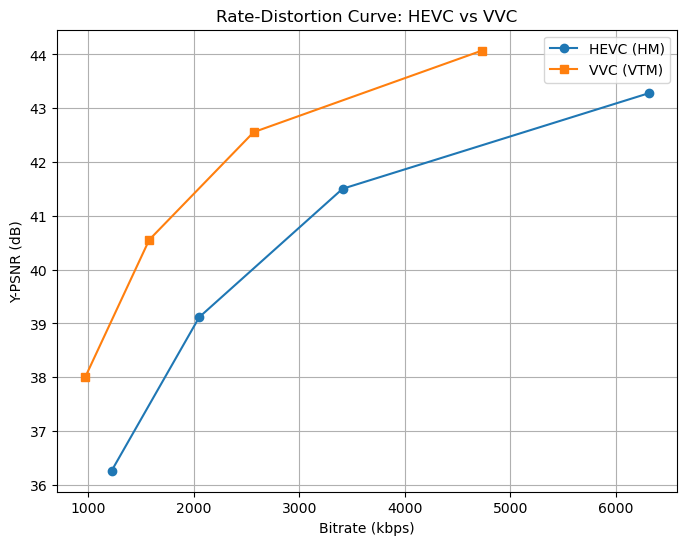

In [3]:
# 3. Plot the Rate-Distortion Curve
plt.figure(figsize=(8, 6))

# Plot HM
plt.plot(hm_data['Bitrate_kbps'], hm_data['Y_PSNR_dB'], 
         marker='o', linestyle='-', label='HEVC (HM)')

# Plot VTM
plt.plot(vtm_data['Bitrate_kbps'], vtm_data['Y_PSNR_dB'], 
         marker='s', linestyle='-', label='VVC (VTM)')

plt.xlabel('Bitrate (kbps)')
plt.ylabel('Y-PSNR (dB)')
plt.title('Rate-Distortion Curve: HEVC vs VVC')
plt.legend()
plt.grid(True)

plt.show()

In [4]:
# 4. Calculate BD-Rate
rate_hm = hm_data['Bitrate_kbps'].values
psnr_hm = hm_data['Y_PSNR_dB'].values

rate_vtm = vtm_data['Bitrate_kbps'].values
psnr_vtm = vtm_data['Y_PSNR_dB'].values

# Calculate BD-Rate using the library
bd_rate_result = bd.bd_rate(rate_hm, psnr_hm, rate_vtm, psnr_vtm, min_overlap=0, method='pchip')

# Print the result
print(f"BD-Rate (VVC vs HEVC): {bd_rate_result:.2f}%")

BD-Rate (VVC vs HEVC): -43.36%


In [5]:
# 5. Complexity Penalty
# Calculate the encoding time ratio for each QP
time_ratio = vtm_data['Time_sec'].values / hm_data['Time_sec'].values

# Create a clean summary dataframe for display
complexity_df = pd.DataFrame({
    'QP': [22, 27, 32, 37],
    'HM Time (s)': hm_data['Time_sec'].values,
    'VTM Time (s)': vtm_data['Time_sec'].values,
    'Ratio': time_ratio
})

# Apply the formatting to the 'Ratio' column to get the "x" string format
complexity_df['Ratio'] = complexity_df['Ratio'].apply(lambda x: f"{x:.2f}x")

# Calculate the average ratio
avg_ratio = time_ratio.mean()

print("--- Encoding Time Complexity ---")
print(complexity_df.to_string(index=False))
print(f"\nAverage Encoding Time Ratio: {avg_ratio:.2f}x")

--- Encoding Time Complexity ---
 QP  HM Time (s)  VTM Time (s) Ratio
 22       89.504       570.181 6.37x
 27       74.017       334.987 4.53x
 32       69.112       221.358 3.20x
 37       61.474       152.397 2.48x

Average Encoding Time Ratio: 4.14x
